# 教師あり学習 ― 分類タスク
南極 Palmer 基地の Kristen Gorman 博士から提供された 3種類のペンギンの体の計測データから，ペンギンの種類を推定する (ペンギンを分類する) AI (分類器) を，教師あり学習によって作成する

## ペンギンのデータ (penguins) の取得<br><span style="font-size:60%;">　(参照： https://github.com/allisonhorst/palmerpenguins/blob/main/README.md)</span>

In [1]:
import requests     # Web上のデータを取得するライブラリをインポートする
import io           # 入出力用のライブラリをインポートする
import pandas as pd # pandas ライブラリを pd という名前でインポートする

# CSVファイルのURL
url_penguins = 'https://github.com/allisonhorst/palmerpenguins/raw/main/inst/extdata/penguins.csv'

# url_penguins のCSVファイルを取得して，データフレーム形式にして df_penguins に保存
df_penguins = pd.read_csv(io.BytesIO(requests.get(url_penguins).content))

# df_penguins に保存したデータフレームを表示
display(df_penguins)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


-   途中が省略されているが，全部で344件 (0～343) ある
-   `NaN` は欠損値を表す
-   `df_penguins` の内容：
    |列 (属性)         |内容              |備考           |
    |----------------:|:-----------------|:--------------|
    |          species|種                |Adelie, Chinstrap, Gentoo の3種．下図参照|
    |           island|生息地 (島)        |今回は使用しない|
    |   bill_length_mm|くちばしの長さ (mm)|下図参照        |
    |    bill_depth_mm|くちばしの深さ (mm)|下図参照        |
    |flipper_length_mm|翼の長さ (mm)      |今回は使用しない|
    |      body_mass_g|体重 (g)          |今回は使用しない|
    |              sex|性別              |今回は使用しない|
    |             year|測定年             |今回は使用しない|

    <img src="https://raw.githubusercontent.com/allisonhorst/palmerpenguins/refs/heads/main/man/figures/lter_penguins.png" style="width:600px;background-color:white;"><br>
    　　　　　ヒゲペンギン　　　ジェンツーペンギン　　　アデリーペンギン

    <img src="https://raw.githubusercontent.com/allisonhorst/palmerpenguins/refs/heads/main/man/figures/culmen_depth.png" style="width:600px"><br>
　　　　　　　　　　　　　　　　　　　　　 Both artworks by @allison_horst

In [2]:
# df_penguins の各列の基本統計量を表示
display(df_penguins.describe())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [3]:
# 説明変数（問題）と目的変数（正解）を設定する
X_vars = ['bill_length_mm', 'bill_depth_mm']
y_var = 'species'

# 説明変数と目的変数を合わせたデータフレームを作成し， 
# 欠損値 (NaN) を含む行を削除
df = df_penguins[X_vars + [y_var]].dropna()

x = df[X_vars]  # 説明変数のデータフレーム
y = df[y_var]   # 目的変数のシリーズ（列）

display(df)

,bill_length_mm,bill_depth_mm,species
0,39.1,18.7,Adelie
1,39.5,17.4,Adelie
2,40.3,18.0,Adelie
4,36.7,19.3,Adelie
5,39.3,20.6,Adelie
...,...,...,...
339,55.8,19.8,Chinstrap
340,43.5,18.1,Chinstrap
341,49.6,18.2,Chinstrap
342,50.8,19.0,Chinstrap


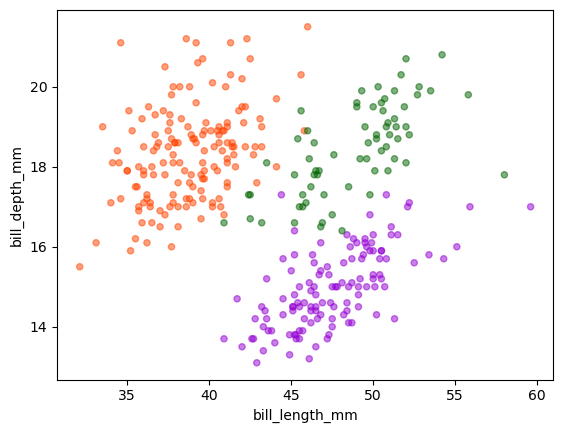

In [4]:
# 散布図の表示
color_map = {'Adelie':'orangered', 'Chinstrap':'darkgreen', 'Gentoo':'darkviolet'}
_ = df.plot.scatter(
    x=X_vars[0], y=X_vars[1],
    c=df[y_var].replace(color_map),
    alpha=0.5,
)

-   <span style="background-color: orangered">　</span> Adelie（アデリーペンギン）   
-   <span style="background-color: darkgreen">　</span> Chinstrap（ヒゲペンギン）   
-   <span style="background-color: darkviolet">　</span> Gentoo（ジェンツーペンギン）   

## 訓練データとテストデータの分割

In [5]:
# データをランダムに分割するためのライブラリ train_test_split をインポートする
from sklearn.model_selection import train_test_split

# 元データを訓練データとテストデータに分割する
#   train_size：    訓練データの割合または個数 (デフォルトは75%)
#   test_size：     テストデータの割合または個数 (デフォルトは25%)
#   random_state：  乱数の seed (種子)— 0以上4294967295以下の任意の整数
#                   (同じ値に対しては，毎回同じように分割される)
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=15)

# 結果的に以下のように分割される (変数ビュー (上の[変数]ボタンで開く) で確認してみよう)
#   X_train：   訓練データの説明変数 (y_train と1対1に対応する) — 342の約75%，256組のデータとなる
#   X_test：    テストデータの説明変数 (y_test と1対1に対応する) — 342の約25%，86組のデータとなる
#   y_train：   訓練データの目的変数 (X_train と1対1に対応する) — 342の約75%，256個のデータとなる
#   y_test：    テストデータの目的変数 (X_test と1対1に対応する) — 342の約25%，86個のデータとなる

# 各データのデータ数 (行数) を表示
print("X_train のデータ数 (行数):", len(X_train), ", X_test のデータ数 (行数):", len(X_test))
print("y_train のデータ数 (行数):", len(y_train), ", y_test のデータ数 (行数):", len(y_test))

X_train のデータ数 (行数): 256 , X_test のデータ数 (行数): 86
y_train のデータ数 (行数): 256 , y_test のデータ数 (行数): 86


## 決定木を用いた分類器(1)

In [6]:
# 決定木学習による分類器のモジュール DecisionTreeClassifier をインポートする
from sklearn.tree import DecisionTreeClassifier
# 決定木モデルの生成
model_dt = DecisionTreeClassifier(random_state=0)
model_dt.fit(X_train, y_train)                      # 学習の実行

# 結果の表示
from sklearn.metrics import confusion_matrix

print('【訓練データ】')
df_predict = pd.DataFrame(model_dt.predict(X_train), columns=['predict'], index=X_train.index)
print(confusion_matrix(y_train, df_predict))                # 混同行列の表示
ok = len(y_train[y_train==df_predict.predict])
print(f"誤判定数: {len(X_train)-ok} / {len(X_train)}")       # 誤判定数の表示
dt_train_score = 100*ok/len(X_train)
print(f"正解率　: {'{:.1f}'.format(dt_train_score)}%")      # 正解率の表示

print('\n【テストデータ】')
#showResults(model_dt, X_test, y_test)
df_predict = pd.DataFrame(model_dt.predict(X_test), columns=['predict'], index=X_test.index)
print(confusion_matrix(y_test, df_predict))                 # 混同行列の表示
ok = len(y_test[y_test==df_predict.predict])
print(f"誤判定数: {len(X_test)-ok} / {len(X_test)}")         # 誤判定数の表示
dt_test_score = 100*ok/len(X_test)
print(f"正解率　: {'{:.1f}'.format(dt_test_score)}%")      # 正解率の表示

【訓練データ】
[[118   0   0]
 [  0  44   0]
 [  0   0  94]]
誤判定数: 0 / 256
正解率　: 100.0%

【テストデータ】
[[30  3  0]
 [ 2 21  1]
 [ 0  1 28]]
誤判定数: 7 / 86
正解率　: 91.9%


**混同行列の見方**
```
[[30  3  0]
 [ 2 19  3]
 [ 0  1 28]]
```
-  各行 (数の横の並び) は，データの元の「ペンギンの種類」 (*species*) に対応する  
    (上から *Adelie*, *Chinstrap*, *Gentoo*)
-  各列 (数の縦の並び) は，データに対して判定された「ペンギンの種類」 (*predict*)  
    に対応する (左から *Adelie*, *Chinstrap*, *Gentoo*)
-  対角線にあたる成分が正しく判定された分，それ以外が正しく判定されなかった分になる

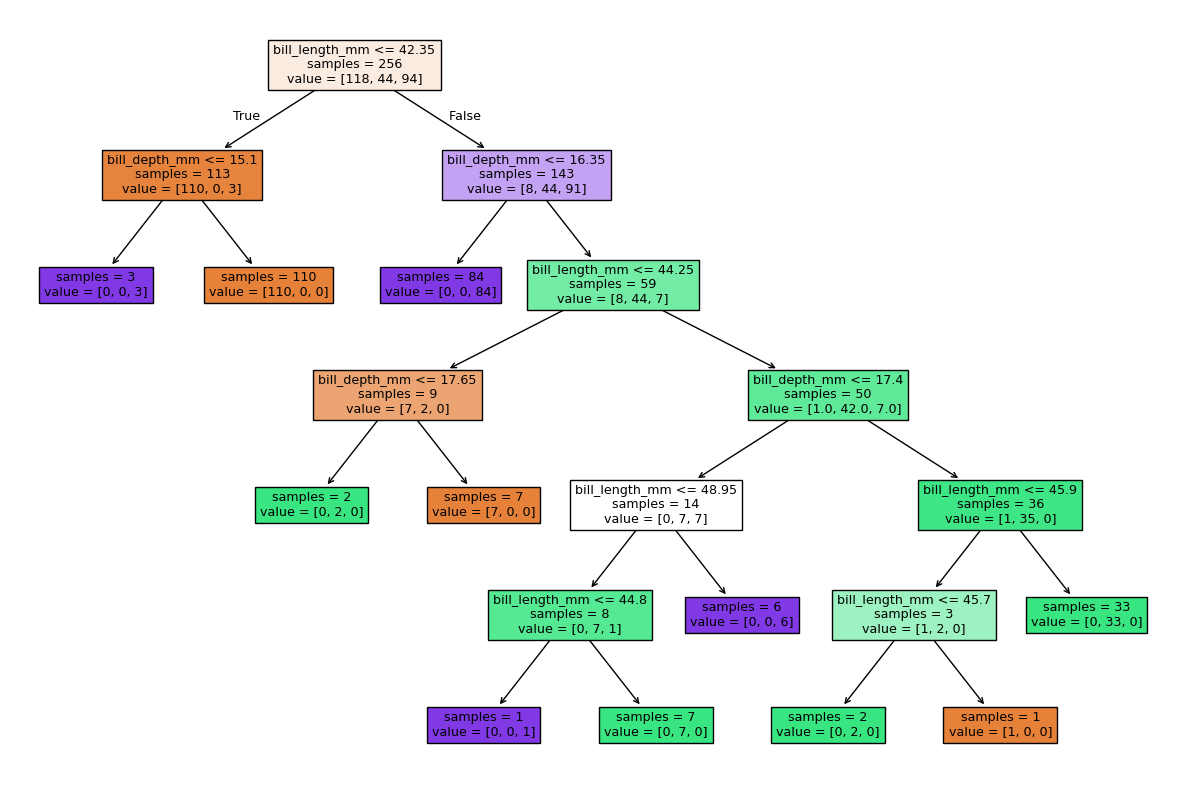

【訓練データ】


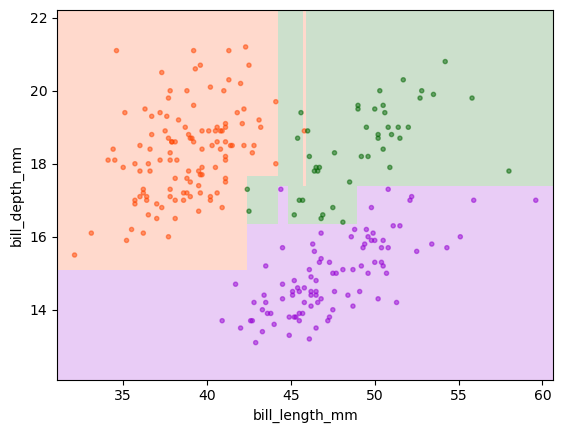

【テストデータ】


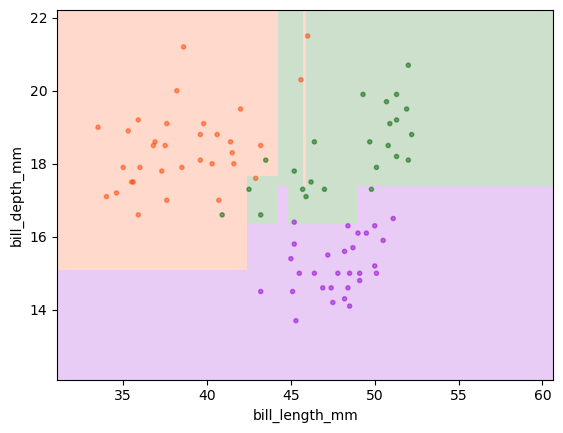

In [7]:
# 決定木の表示
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 10))
plot_tree(model_dt, feature_names=X_vars, impurity=False, filled=True)
plt.show()

# 決定境界図の表示
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay
print('【訓練データ】')
disp = DecisionBoundaryDisplay.from_estimator(model_dt, X_train,
    plot_method='pcolormesh',
    grid_resolution=400,
    cmap=ListedColormap(color_map.values()),
    xlabel=X_train.columns[0], ylabel=X_train.columns[1],
    alpha=0.2
)
disp.ax_.scatter(
    x=X_train.iloc[:, [0]], y=X_train.iloc[:, [1]],
    marker='.',
    c=y_train.replace(color_map),
    alpha=0.5
)
plt.show()
print('【テストデータ】')
disp = DecisionBoundaryDisplay.from_estimator(model_dt, X_train,
    plot_method='pcolormesh',
    grid_resolution=400,
    cmap=ListedColormap(color_map.values()),
    xlabel=X_train.columns[0], ylabel=X_train.columns[1],
    alpha=0.2
)
disp.ax_.scatter(
    x=X_test.iloc[:, [0]], y=X_test.iloc[:, [1]],
    marker='.',
    c=y_test.replace(color_map),
    alpha=0.5
)
plt.show()

## 決定木を用いた分類器(2)

In [8]:
# 決定木学習による分類器のモジュール DecisionTreeClassifier をインポートする
from sklearn.tree import DecisionTreeClassifier
# 決定木モデルの生成 (ハイパーパラメータを追加してチューニング)
#   min_samples_leaf:   末端ノードに対応するサンプルの最小値 (デフォルトは1)
#   max_leaf_nodes:     末端ノードの総数の最大値 (デフォルトはNone(上限なし))
model_dt2 = DecisionTreeClassifier(random_state=7, min_samples_leaf=3, max_leaf_nodes=8)
model_dt2.fit(X_train, y_train)          # 学習の実行

# 結果の表示
from sklearn.metrics import confusion_matrix

print('【訓練データ】')
df_predict = pd.DataFrame(model_dt2.predict(X_train), columns=['predict'], index=X_train.index)
print(confusion_matrix(y_train, df_predict))                # 混同行列の表示
ok = len(y_train[y_train==df_predict.predict])
print(f"誤判定数: {len(X_train)-ok} / {len(X_train)}")       # 誤判定数の表示
dt2_train_score = 100*ok/len(X_train)
print(f"正解率　: {'{:.1f}'.format(dt2_train_score)}%")      # 正解率の表示

print('\n【テストデータ】')
#showResults(model_dt2, X_test, y_test)
df_predict = pd.DataFrame(model_dt2.predict(X_test), columns=['predict'], index=X_test.index)
print(confusion_matrix(y_test, df_predict))                 # 混同行列の表示
ok = len(y_test[y_test==df_predict.predict])
print(f"誤判定数: {len(X_test)-ok} / {len(X_test)}")         # 誤判定数の表示
dt2_test_score = 100*ok/len(X_test)
print(f"正解率　: {'{:.1f}'.format(dt2_test_score)}%")      # 正解率の表示

【訓練データ】
[[116   2   0]
 [  0  44   0]
 [  0   1  93]]
誤判定数: 3 / 256
正解率　: 98.8%

【テストデータ】
[[30  3  0]
 [ 1 22  1]
 [ 0  1 28]]
誤判定数: 6 / 86
正解率　: 93.0%


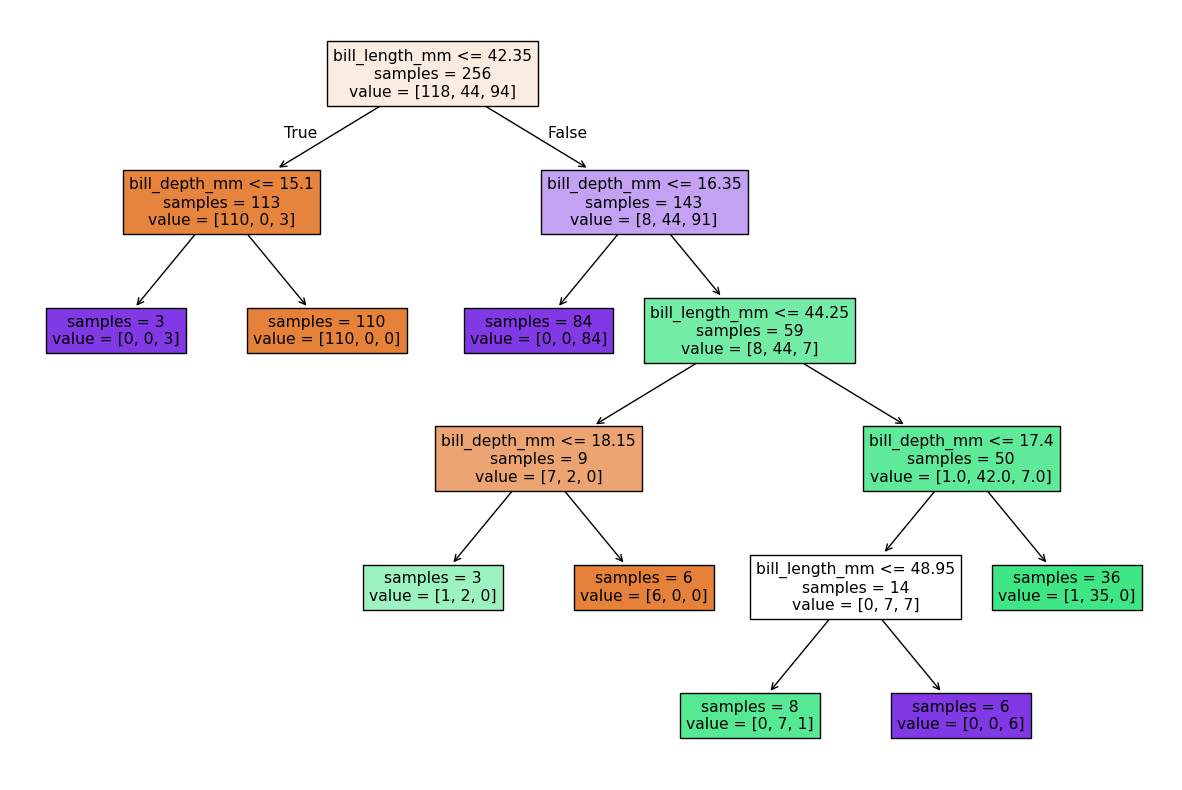

【訓練データ】


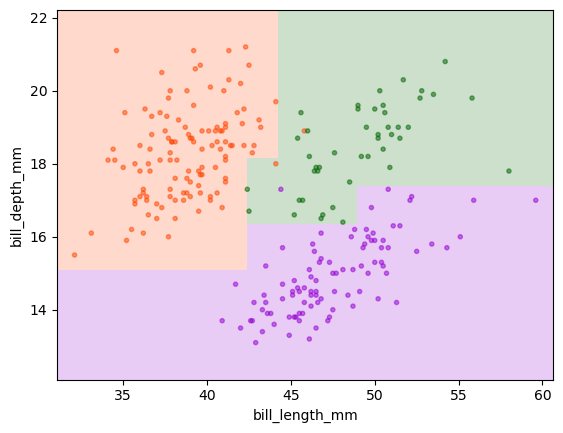

【テストデータ】


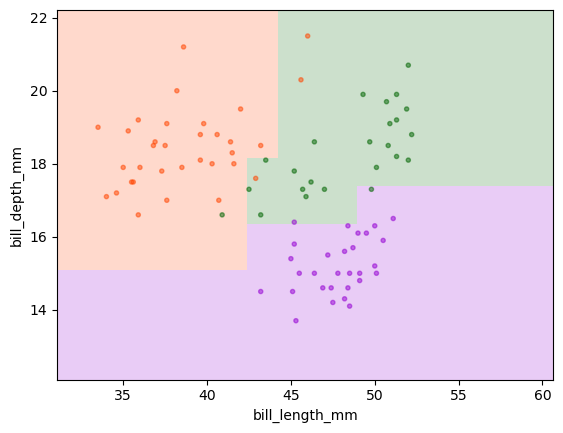

In [9]:
# 決定木の表示
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 10))
plot_tree(model_dt2, feature_names=X_vars, impurity=False, filled=True)
plt.show()

# 決定境界図の表示
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay
print('【訓練データ】')
disp = DecisionBoundaryDisplay.from_estimator(model_dt2, X_train,
    plot_method='pcolormesh',
    grid_resolution=400,
    cmap=ListedColormap(color_map.values()),
    xlabel=X_train.columns[0], ylabel=X_train.columns[1],
    alpha=0.2
)
disp.ax_.scatter(
    x=X_train.iloc[:, [0]], y=X_train.iloc[:, [1]],
    marker='.',
    c=y_train.replace(color_map),
    alpha=0.5
)
plt.show()
print('【テストデータ】')
disp = DecisionBoundaryDisplay.from_estimator(model_dt2, X_train,
    plot_method='pcolormesh',
    grid_resolution=400,
    cmap=ListedColormap(color_map.values()),
    xlabel=X_train.columns[0], ylabel=X_train.columns[1],
    alpha=0.2
)
disp.ax_.scatter(
    x=X_test.iloc[:, [0]], y=X_test.iloc[:, [1]],
    marker='.',
    c=y_test.replace(color_map),
    alpha=0.5
)
plt.show()

## ランダムフォレストを用いた分類器

In [10]:
# ランダムフォレストによる分類器のモジュール RandomForestClassifier をインポートする
from sklearn.ensemble import RandomForestClassifier
# ランダムフォレストモデルの生成
#   n_estimators:   決定木の数 (デフォルトは100)
model_rf = RandomForestClassifier(random_state=0)
model_rf.fit(X_train, y_train)                      # 学習の実行

# 結果の表示
from sklearn.metrics import confusion_matrix

print('【訓練データ】')
df_predict = pd.DataFrame(model_rf.predict(X_train), columns=['predict'], index=X_train.index)
print(confusion_matrix(y_train, df_predict))                # 混同行列の表示
ok = len(y_train[y_train==df_predict.predict])
print(f"誤判定数: {len(X_train)-ok} / {len(X_train)}")       # 誤判定数の表示
rf_train_score = 100*ok/len(X_train)
print(f"正解率　: {'{:.1f}'.format(rf_train_score)}%")      # 正解率の表示

print('\n【テストデータ】')
#showResults(model_rf, X_test, y_test)
df_predict = pd.DataFrame(model_rf.predict(X_test), columns=['predict'], index=X_test.index)
print(confusion_matrix(y_test, df_predict))                 # 混同行列の表示
ok = len(y_test[y_test==df_predict.predict])
print(f"誤判定数: {len(X_test)-ok} / {len(X_test)}")         # 誤判定数の表示
rf_test_score = 100*ok/len(X_test)
print(f"正解率　: {'{:.1f}'.format(rf_test_score)}%")      # 正解率の表示

【訓練データ】
[[118   0   0]
 [  0  44   0]
 [  0   0  94]]
誤判定数: 0 / 256
正解率　: 100.0%

【テストデータ】
[[31  2  0]
 [ 2 21  1]
 [ 0  1 28]]
誤判定数: 6 / 86
正解率　: 93.0%


【訓練データ】


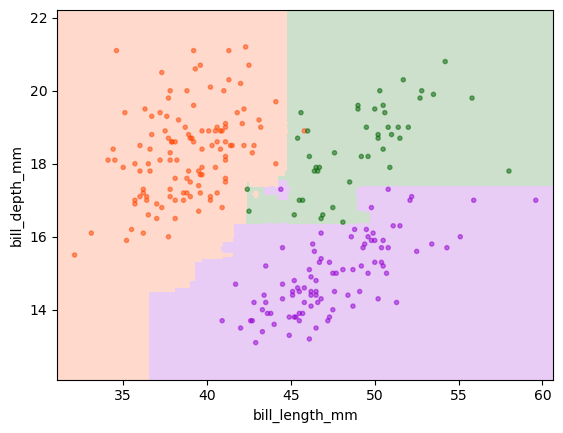

【テストデータ】


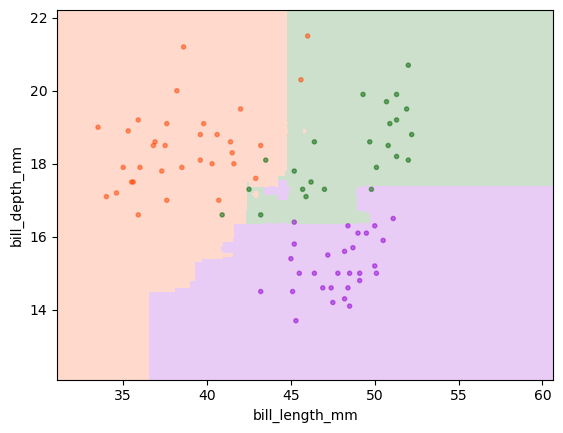

In [11]:
# 決定境界図の表示
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay
print('【訓練データ】')
disp = DecisionBoundaryDisplay.from_estimator(model_rf, X_train,
    plot_method='pcolormesh',
    grid_resolution=400,
    cmap=ListedColormap(color_map.values()),
    xlabel=X_train.columns[0], ylabel=X_train.columns[1],
    alpha=0.2
)
disp.ax_.scatter(
    x=X_train.iloc[:, [0]], y=X_train.iloc[:, [1]],
    marker='.',
    c=y_train.replace(color_map),
    alpha=0.5
)
plt.show()
print('【テストデータ】')
disp = DecisionBoundaryDisplay.from_estimator(model_rf, X_train,
    plot_method='pcolormesh',
    grid_resolution=400,
    cmap=ListedColormap(color_map.values()),
    xlabel=X_train.columns[0], ylabel=X_train.columns[1],
    alpha=0.2
)
disp.ax_.scatter(
    x=X_test.iloc[:, [0]], y=X_test.iloc[:, [1]],
    marker='.',
    c=y_test.replace(color_map),
    alpha=0.5
)
plt.show()

## ニューラルネットワーク (2層FNN) を用いた分類器

【訓練データ】
[[117   1   0]
 [  3  34   7]
 [  0   1  93]]
誤判定数: 12 / 256
正解率　: 95.3%

【テストデータ】
[[33  0  0]
 [ 1 20  3]
 [ 0  1 28]]
誤判定数: 5 / 86
正解率　: 94.2%


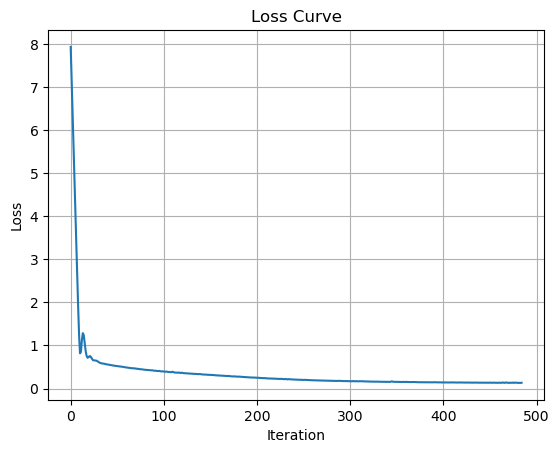

In [12]:
# FNNによる分類器のモジュール MLPClassifier をインポートする
from sklearn.neural_network import MLPClassifier
# 2層FNNモデルの生成
#   max_iter:           学習の最大反復回数 (デフォルトの200では収束しないので大きくしている)
#   hidden_layer_sizes: 隠れ層の数と各層のユニット数 (デフォルトは (100,) : 100ユニット×1層)
model_mlp = MLPClassifier(random_state=0, max_iter=500)
model_mlp.fit(X_train, y_train)                         # 学習の実行

# 結果の表示
from sklearn.metrics import confusion_matrix

print('【訓練データ】')
df_predict = pd.DataFrame(model_mlp.predict(X_train), columns=['predict'], index=X_train.index)
print(confusion_matrix(y_train, df_predict))                # 混同行列の表示
ok = len(y_train[y_train==df_predict.predict])
print(f"誤判定数: {len(X_train)-ok} / {len(X_train)}")       # 誤判定数の表示
mlp_train_score = 100*ok/len(X_train)
print(f"正解率　: {'{:.1f}'.format(mlp_train_score)}%")      # 正解率の表示

print('\n【テストデータ】')
#showResults(model_mlp, X_test, y_test)
df_predict = pd.DataFrame(model_mlp.predict(X_test), columns=['predict'], index=X_test.index)
print(confusion_matrix(y_test, df_predict))                 # 混同行列の表示
ok = len(y_test[y_test==df_predict.predict])
print(f"誤判定数: {len(X_test)-ok} / {len(X_test)}")         # 誤判定数の表示
mlp_test_score = 100*ok/len(X_test)
print(f"正解率　: {'{:.1f}'.format(mlp_test_score)}%")      # 正解率の表示

# Loss Curve (反復回数による誤差の変動) の表示
import matplotlib.pyplot as plt
plt.title("Loss Curve")
plt.plot(model_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()

【訓練データ】


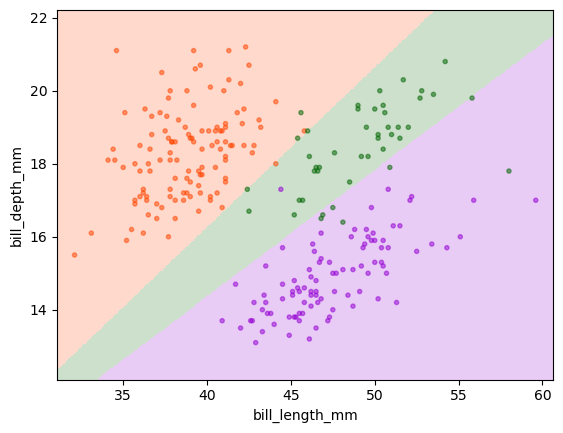

【テストデータ】


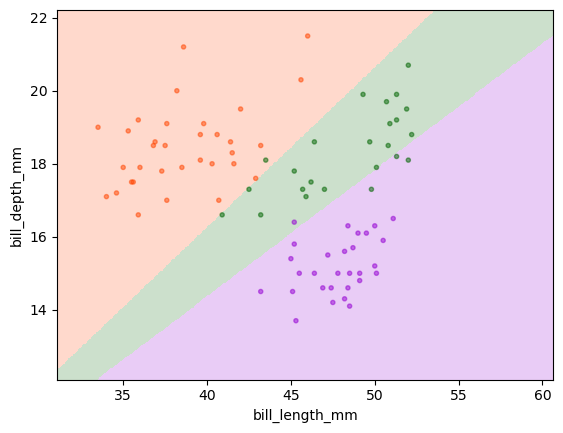

In [13]:
# 決定境界図の表示
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay
print('【訓練データ】')
disp = DecisionBoundaryDisplay.from_estimator(model_mlp, X_train,
    plot_method='pcolormesh',
    grid_resolution=400,
    cmap=ListedColormap(color_map.values()),
    xlabel=X_train.columns[0], ylabel=X_train.columns[1],
    alpha=0.2
)
disp.ax_.scatter(
    x=X_train.iloc[:, [0]], y=X_train.iloc[:, [1]],
    marker='.',
    c=y_train.replace(color_map),
    alpha=0.5
)
plt.show()
print('【テストデータ】')
disp = DecisionBoundaryDisplay.from_estimator(model_mlp, X_train,
    plot_method='pcolormesh',
    grid_resolution=400,
    cmap=ListedColormap(color_map.values()),
    xlabel=X_train.columns[0], ylabel=X_train.columns[1],
    alpha=0.2
)
disp.ax_.scatter(
    x=X_test.iloc[:, [0]], y=X_test.iloc[:, [1]],
    marker='.',
    c=y_test.replace(color_map),
    alpha=0.5
)
plt.show()

## 正解率のまとめ

In [14]:
# 正解率のまとめ

print("正解率：　　　　　　　訓練データ　→　テストデータ")
print(f"　　決定木(1):　　　　　　{'{:.1f}'.format(dt_train_score)}%　→　{'{:.1f}'.format(dt_test_score)}%")
print(f"　　決定木(2):　　　　　 　{'{:.1f}'.format(dt2_train_score)}%　→　{'{:.1f}'.format(dt2_test_score)}%")
print(f"　　ランダムフォレスト:　　{'{:.1f}'.format(rf_train_score)}%　→　{'{:.1f}'.format(rf_test_score)}%")
print(f"　　FNN:　　　　　　　　 　{'{:.1f}'.format(mlp_train_score)}%　→　{'{:.1f}'.format(mlp_test_score)}%")


正解率：　　　　　　　訓練データ　→　テストデータ
　　決定木(1):　　　　　　100.0%　→　91.9%
　　決定木(2):　　　　　 　98.8%　→　93.0%
　　ランダムフォレスト:　　100.0%　→　93.0%
　　FNN:　　　　　　　　 　95.3%　→　94.2%


## 考えてみよう
- 各モデルのテストデータの正解率を比べてみよう
  - 正解率の高いのはどれ？
- 各モデルで，訓練データとテストデータの正解率を比べてみよう
  - 訓練データとテストデータの差が大きいものはどれ？ 小さいものは？  
    → 正解率が大きく下がるのは，過学習の可能性がある
- 各モデルの決定境界図を見比べてみよう
  - 過学習になっていそうなのはどれ？
    → 不自然に入り組んだ図の場合，過学習の可能性がある
